<a href="https://colab.research.google.com/github/Cruz255/ie332-fall2026/blob/main/ie332-fall2026/assignments/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---


AI Reflection:
Our team used generative AI for troubleshooting and debugging throughout the SQL query process, such as with the composite question 9 in Part A. This helped the team learn to apply CASE, PARTITION BY, and use CTE's more effectively. When using it in these cases, we checked the AI for any errors it would make when analyzing our program. In the final report, we did not identify an error.




---


Initial Setup:

In [47]:
# Boilermaker Brews setup.
from pathlib import Path
import sqlite3
import pandas as pd
from IPython.display import display

DB_PATH = Path("boilermaker_brews.db")

if not DB_PATH.exists():
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            "Place boilermaker_brews.db in the notebook's working folder."
        ) from exc
    print("Choose boilermaker_brews.db from the course files.")
    files.upload()

if not DB_PATH.exists():
    raise FileNotFoundError("boilermaker_brews.db was not uploaded.")

conn = sqlite3.connect(DB_PATH)


class SQLResult(list):
    """The rows of a query, plus .keys so the self-checks can name columns."""
    def __init__(self, frame):
        super().__init__(frame.itertuples(index=False, name=None))
        self.keys = list(frame.columns)
        self.frame = frame


def _sql_magic(line, cell):
    """%%sql             run and display
       %%sql q1 <<       run, display, and store the result in q1
       %%sql q1          same thing; the << is optional"""
    target = line.replace("<<", " ").strip().split(None, 1)[0] if line.strip() else None
    statement = cell.strip()
    if statement.split(None, 1)[0].upper() in {"SELECT", "WITH", "PRAGMA", "EXPLAIN"}:
        frame = pd.read_sql_query(statement, conn)
        display(frame)
        if target:
            get_ipython().user_ns[target] = SQLResult(frame)
        return
    conn.executescript(statement)
    conn.commit()
    print("Statement executed successfully.")


get_ipython().register_magic_function(_sql_magic, "cell", "sql")

def _sql_line_magic(line):
    """%sql SELECT ...   one-liner form, used by the smoke test."""
    _sql_magic("", line)


get_ipython().register_magic_function(_sql_line_magic, "line", "sql")

n = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM sqlite_master WHERE type='table';", conn
).iloc[0, 0]
print(f"Connected to {DB_PATH.name}: {n} tables. The %%sql command is ready.")

Connected to boilermaker_brews.db: 6 tables. The %%sql command is ready.




---


Part A: SQL on Boilermaker Brews

In [48]:
#Q1a Revenue and units by category.

%%sql
SELECT p.category,
       printf('%.2f', SUM(oi.quantity * oi.unit_price)) AS total_revenue,
       SUM(oi.quantity) AS units_sold
FROM order_items AS oi
JOIN products AS p ON p.product_id = oi.product_id
GROUP BY p.category
ORDER BY SUM(oi.quantity * oi.unit_price) DESC

,category,total_revenue,units_sold
0,espresso,197025.25,41410
1,brew,67355.30,18175
2,tea,44795.50,12196
3,pastry,39935.30,13168
4,food,21793.25,2963
5,merch,3310.00,334


In [49]:
#Q1b Revenue and units by category.

%%sql
SELECT p.category,
       printf('%.2f', SUM(oi.quantity * oi.unit_price)) AS total_revenue,
       SUM(oi.quantity) AS units_sold
FROM order_items AS oi
JOIN products AS p ON p.product_id = oi.product_id
GROUP BY p.category
ORDER BY SUM(oi.quantity) DESC

,category,total_revenue,units_sold
0,espresso,197025.25,41410
1,brew,67355.30,18175
2,pastry,39935.30,13168
3,tea,44795.50,12196
4,food,21793.25,2963
5,merch,3310.00,334


Tea and pastry switch positions when ordered by revenue and units sold. Tea has higher revenue (44,795.5 vs 39,935.30), but pastry sells more units (13,168 vs 12,196). This happened because tea generates more revenue per unit sold.

In [50]:
#Q2a App-order share by café.

%%sql
WITH shares AS (
    SELECT s.store_id,
           s.name AS cafe,
           1.0 * SUM(CASE WHEN o.channel = 'app' THEN 1 ELSE 0 END)
               / COUNT(*) AS share
    FROM orders AS o
    JOIN stores AS s ON s.store_id = o.store_id
    GROUP BY s.store_id, s.name
)
SELECT cafe,
       printf('%.3f', share) AS app_order_share
FROM shares
ORDER BY share DESC, cafe

,cafe,app_order_share
0,Chauncey Hill,0.305
1,Airport Rd Drive-Thru,0.302
2,Levee Plaza,0.301
3,PMU Ground Floor,0.300
4,Discovery Park,0.295
5,State Street East,0.295


In [51]:
#Q2b App-order share by café.

%%sql
WITH shares AS (
    SELECT stores.name AS cafe,
           1.0 * SUM(CASE WHEN channel = 'app' THEN 1 ELSE 0 END)
           / COUNT(*) AS share
    FROM orders
    JOIN stores ON orders.store_id = stores.store_id
    GROUP BY stores.store_id, stores.name
),
lowest AS (
    SELECT cafe, share
    FROM shares
    ORDER BY share ASC
    LIMIT 1
)
SELECT cafe AS highest_cafe,
       ROUND(share, 6) AS highest_share,
       (SELECT cafe FROM lowest) AS lowest_cafe,
       ROUND((SELECT share FROM lowest), 6) AS lowest_share,
       ROUND(share - (SELECT share FROM lowest), 6) AS difference
FROM shares
ORDER BY share DESC
LIMIT 1

,highest_cafe,highest_share,lowest_cafe,lowest_share,difference
0,Chauncey Hill,0.304657,State Street East,0.295098,0.009558


App-order shares are similar across cafés, at around 30%. Chauncey Hill has the highest share (0.304657), and State Street East has the lowest (0.295098). The difference is only 0.009558, or about 0.956 percentage points.

In [52]:
#Q3 Highest-spending customers.

%%sql
SELECT customers.customer_id,
       customers.name,
       ROUND(SUM(quantity * unit_price), 0) AS spending
FROM customers
JOIN orders ON customers.customer_id = orders.customer_id
JOIN order_items ON orders.order_id = order_items.order_id
GROUP BY customers.customer_id, customers.name
ORDER BY SUM(quantity * unit_price) DESC
LIMIT 3

,customer_id,name,spending
0,439,Wei Shah,628.0
1,360,Priya Nguyen,602.0
2,259,Mateo Kim,594.0


In [53]:
#Q4 Average spending per order by loyalty tier.

%%sql
WITH order_totals AS (
    SELECT order_id,
           SUM(quantity * unit_price) AS order_value
    FROM order_items
    GROUP BY order_id
)
SELECT CASE
           WHEN orders.customer_id IS NULL THEN 'walk-in'
           ELSE customers.loyalty_tier
       END AS tier,
       ROUND(AVG(order_value), 2) AS average_order_value,
       COUNT(*) AS number_of_orders
FROM orders
JOIN order_totals ON orders.order_id = order_totals.order_id
LEFT JOIN customers ON orders.customer_id = customers.customer_id
GROUP BY tier
ORDER BY CASE tier
             WHEN 'gold' THEN 1
             WHEN 'silver' THEN 2
             WHEN 'none' THEN 3
             WHEN 'walk-in' THEN 4
         END

,tier,average_order_value,number_of_orders
0,gold,7.21,6496
1,silver,7.24,10698
2,none,7.20,16530
3,walk-in,7.19,18203


Average order values are pretty similar: gold is 7.21, silver is
7.24, none is 7.20, and walk-in is 7.19. Higher loyalty tiers
do not consistently spend more per order. This does not show that the program causes more visits or more total spendin:g per customer. We would need visits and total spending per person, and customers may already have different
shopping habits before joining. We also cannot determine profit
without information about costs.

In [54]:
#Q5 Above-average revenue months.

%%sql
WITH monthly_revenue AS (
    SELECT strftime('%Y-%m', order_ts) AS month,
           SUM(quantity * unit_price) AS revenue
    FROM orders
    JOIN order_items ON orders.order_id = order_items.order_id
    GROUP BY strftime('%Y-%m', order_ts)
)
SELECT month,
       ROUND(revenue, 2) AS revenue
FROM monthly_revenue
WHERE revenue > (
    SELECT AVG(revenue)
    FROM monthly_revenue
)
ORDER BY month

,month,revenue
0,2025-09,39629.65
1,2025-10,40557.75
2,2025-11,38093.40
3,2025-12,31841.50
4,2026-02,33479.20
5,2026-03,36437.90
6,2026-04,36347.95


The returned months are in fall and spring. All fall months
(September – December) are above average, with revenues ranging
from 31,841.50 to 40,557.75. February – April are also above
average, with revenues from 33,479.20 to 36,437.90.
January and all summer months are not above average.

In [55]:
#Q6 Highest-revenue month for each category.

%%sql
WITH monthly_revenue AS (
    SELECT
        p.category,
        strftime('%Y-%m', o.order_ts) AS month,
        SUM(oi.quantity * oi.unit_price) AS revenue
    FROM order_items oi
    JOIN products p
        ON oi.product_id = p.product_id
    JOIN orders o
        ON oi.order_id = o.order_id
    GROUP BY
        p.category,
        strftime('%Y-%m', o.order_ts)
),
ranked_months AS (
    SELECT
        category,
        month,
        revenue,
        ROW_NUMBER() OVER (PARTITION BY category ORDER BY revenue DESC) AS rank
    FROM monthly_revenue
)
SELECT category, month, revenue
FROM ranked_months
WHERE rank = 1
ORDER BY category

,category,month,revenue
0,brew,2026-03,7485.40
1,espresso,2025-10,25169.25
2,food,2026-04,2609.75
3,merch,2026-04,384.00
4,pastry,2026-04,4549.80
5,tea,2026-03,5285.75


In [56]:
#Q7 Gold members with no recorded merchandise purchases.

%%sql
WITH qualifying_gold_members AS (
    SELECT c.customer_id
    FROM customers c
    WHERE c.loyalty_tier = 'gold'
      AND NOT EXISTS (
          SELECT 1
          FROM orders o
          JOIN order_items oi
              ON o.order_id = oi.order_id
          JOIN products p
              ON oi.product_id = p.product_id
          WHERE o.customer_id = c.customer_id
            AND p.category = 'merch'
      )
)
SELECT
    COUNT(*) OVER () AS customer_count,
    customer_id
FROM qualifying_gold_members
ORDER BY customer_id ASC
LIMIT 5

,customer_count,customer_id
0,76,6
1,76,21
2,76,24
3,76,34
4,76,39


In [57]:
#Q8 Products sold in fewer than twelve months.

%%sql
SELECT
p.name,
    COUNT(DISTINCT strftime('%Y-%m', o.order_ts)) AS months_sold,
    SUM(oi.quantity) AS total_units
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN products p
    ON oi.product_id = p.product_id
GROUP BY
    p.product_id,
    p.name
HAVING COUNT(DISTINCT strftime('%Y-%m', o.order_ts)) < 12
ORDER BY p.name

,name,months_sold,total_units
0,Peppermint Mocha,4,4426
1,Pumpkin Spice Latte,4,3613


In [58]:
#Q9a Café–daypart results.

%%sql
WITH classified_orders AS (
    SELECT
        o.order_id,
        s.name AS cafe,
        CASE
            WHEN CAST(strftime('%H', o.order_ts) AS INTEGER) BETWEEN 0 AND 10
                THEN 'morning'
            WHEN CAST(strftime('%H', o.order_ts) AS INTEGER) BETWEEN 11 AND 15
                THEN 'afternoon'
            ELSE 'evening'
        END AS daypart
    FROM orders o
    JOIN stores s
        ON o.store_id = s.store_id
),
daypart_counts AS (
    SELECT
        cafe,
        daypart,
        COUNT(*) AS n_orders
    FROM classified_orders
    GROUP BY cafe, daypart
)
SELECT
    cafe,
    daypart,
    n_orders,
    SUM(n_orders) OVER (
        PARTITION BY cafe
    ) AS cafe_orders,
    ROUND(
        1.0 * n_orders /
        SUM(n_orders) OVER (PARTITION BY cafe),
        3
    ) AS share
FROM daypart_counts
ORDER BY cafe, daypart

,cafe,daypart,n_orders,cafe_orders,share
0,Airport Rd Drive-Thru,afternoon,3112,8258,0.377
1,Airport Rd Drive-Thru,evening,1236,8258,0.150
2,Airport Rd Drive-Thru,morning,3910,8258,0.473
3,Chauncey Hill,afternoon,3358,8869,0.379
4,Chauncey Hill,evening,1273,8869,0.144
5,Chauncey Hill,morning,4238,8869,0.478
6,Discovery Park,afternoon,1789,4822,0.371
7,Discovery Park,evening,625,4822,0.130
8,Discovery Park,morning,2408,4822,0.499
9,Levee Plaza,afternoon,2613,7003,0.373


In [59]:
#Q9b Café–daypart results.

%%sql
WITH classified_orders AS (
    SELECT
        o.order_id,
        s.name AS cafe,
        CASE
            WHEN CAST(strftime('%H', o.order_ts) AS INTEGER) BETWEEN 0 AND 10
                THEN 'morning'
            WHEN CAST(strftime('%H', o.order_ts) AS INTEGER) BETWEEN 11 AND 15
                THEN 'afternoon'
            ELSE 'evening'
        END AS daypart
    FROM orders o
    JOIN stores s
        ON o.store_id = s.store_id
),
daypart_counts AS (
    SELECT
        cafe,
        daypart,
        COUNT(*) AS n_orders
    FROM classified_orders
    GROUP BY cafe, daypart
),
cafe_shares AS (
    SELECT
        cafe,
        daypart,
        ROUND(
            1.0 * n_orders /
            SUM(n_orders) OVER (PARTITION BY cafe),
            3
        ) AS share
    FROM daypart_counts
)
SELECT
    daypart,
    MIN(share) AS min_share,
    MAX(share) AS max_share
FROM cafe_shares
GROUP BY daypart
ORDER BY
    CASE daypart
        WHEN 'morning' THEN 1
        WHEN 'afternoon' THEN 2
        WHEN 'evening' THEN 3
    END

,daypart,min_share,max_share
0,morning,0.471,0.499
1,afternoon,0.369,0.379
2,evening,0.130,0.150


In [60]:
#Q9cI Café–daypart results.

%%sql
SELECT
    s.name AS cafe,
    COUNT(*) AS total_orders
FROM orders o
JOIN stores s
    ON o.store_id = s.store_id
GROUP BY s.store_id, s.name
ORDER BY total_orders DESC
LIMIT 1

,cafe,total_orders
0,PMU Ground Floor,16916


In [61]:
#Q9cII Café–daypart results.

%%sql
SELECT
    s.name AS cafe,
    COUNT(*) AS total_orders
FROM orders o
JOIN stores s
    ON o.store_id = s.store_id
GROUP BY s.store_id, s.name
ORDER BY total_orders ASC
LIMIT 1

,cafe,total_orders
0,Discovery Park,4822


In [62]:
#Q10 Employees with the most associated revenue.

%%sql
SELECT
    e.name AS employee_name,
    s.name AS cafe,
    ROUND(SUM(oi.quantity * oi.unit_price), 2) AS revenue
FROM employees e
JOIN orders o
    ON e.employee_id = o.employee_id
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN stores s
    ON e.store_id = s.store_id
GROUP BY
    e.employee_id,
    e.name,
    s.name
ORDER BY revenue DESC
LIMIT 3

,employee_name,cafe,revenue
0,Sofia Singh,PMU Ground Floor,14190.15
1,Riley Bell,PMU Ground Floor,14037.15
2,Felix Lee,PMU Ground Floor,13873.10




---


Part B: Design the Boilermaker Bikes Database

1) Grain statement
- stations: one row represents one bike-share station.
- bikes: one row represents one physical bike.
- members: one row represents one registered member.
- rides: one row represents one completed ride by one member on one bike.
- maintenance_events: one row represents one service event on one bike.
- technicians: one row represents one technician.
- event_technicians: one row represents one technician's participation in one maintenance event.

2. Relationships
- members.member_id 1 — 0..* rides.member_id
- bikes.bike_id 1 — 0..* rides.bike_id
- stations.station_id 1 — 0..* rides.start_station_id
- stations.station_id 1 — 0..* rides.end_station_id
- bikes.bike_id 1 — 0..* maintenance_events.bike_id
- maintenance_events.event_id 1 — 0..* event_technicians.event_id
- technicians.technician_id 1 — 0..* event_technicians.technician_id

- However the member-bike relationship goes through rides and the events-technicians goes through event_technicians. All the others have a direct line.

3. Keys
- The primary keys are: station_id, bike_id, member_id, ride_id, event_id, technician_id
- For the junction table the primary key is: (event_id, technician_id)

- maintenance_events: event_id: E1, E2 bike



---


Entity Relationship Diagram (ERD):

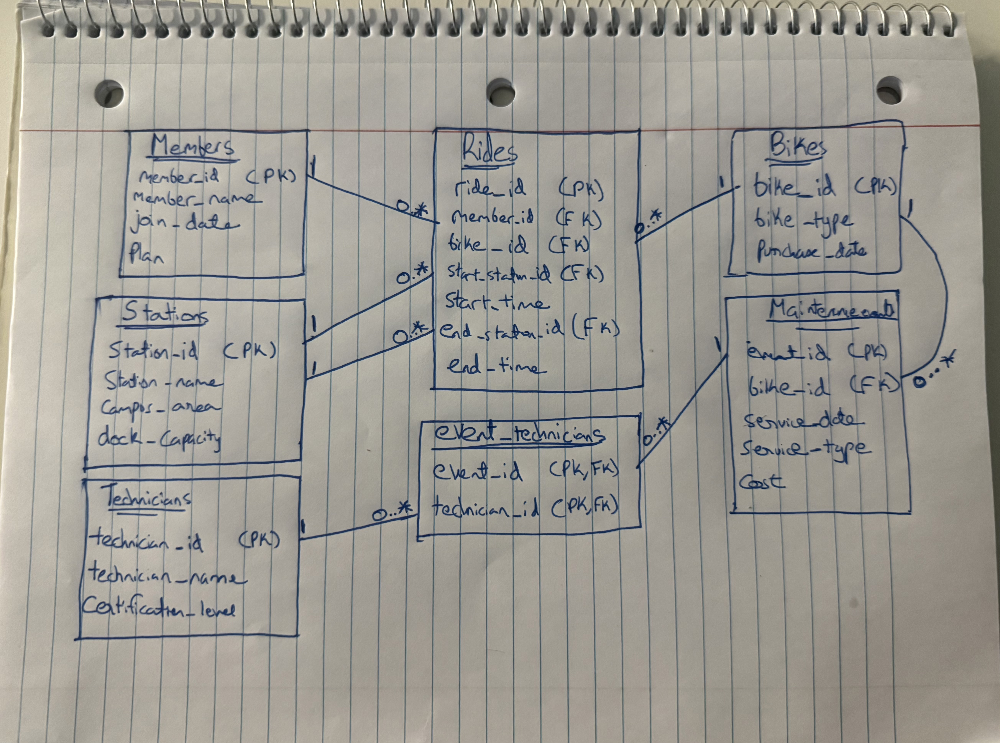

In [63]:
from IPython.display import Image
Image("erd.png", width=650)